In [1]:
!pip install imbalanced-learn tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
df = pd.read_csv('/content/creditcard.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


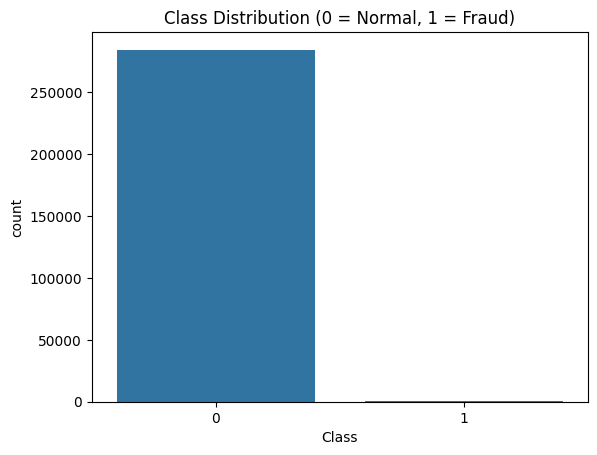

In [5]:
plt.figure()
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

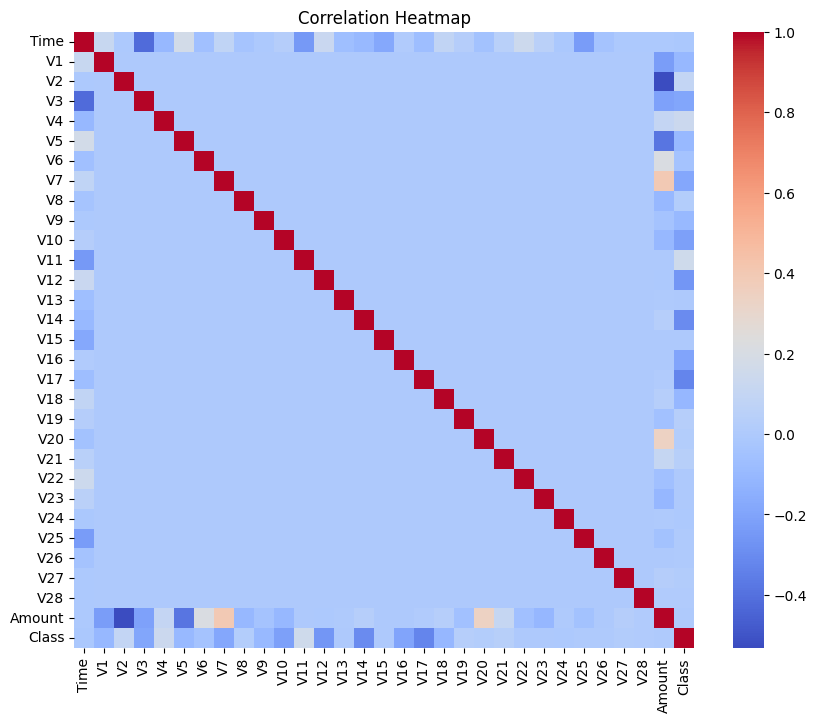

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

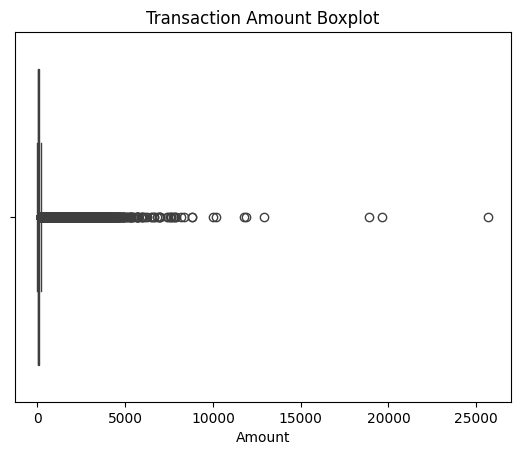

In [7]:
plt.figure()
sns.boxplot(x=df['Amount'])
plt.title("Transaction Amount Boxplot")
plt.show()

In [8]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

df = df.drop(['Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [10]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))


Before SMOTE: [199020    344]
After SMOTE: [199020 199020]


In [11]:
results = []

def evaluate_model(name, model):
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return model, y_pred


Logistic Regression
Accuracy: 0.9767681378228761
Precision: 0.061993323795898905
Recall: 0.8783783783783784
F1 Score: 0.11581291759465479


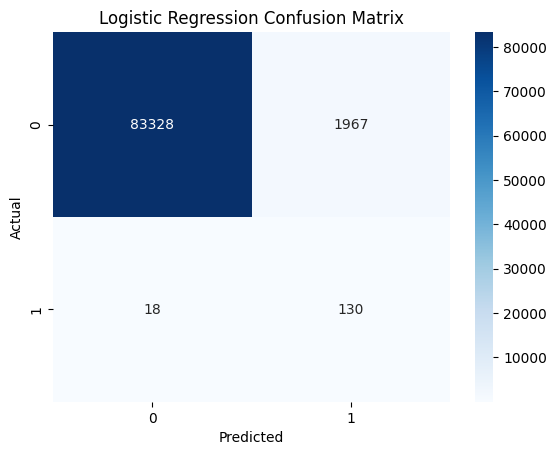


Decision Tree
Accuracy: 0.9972028135716209
Precision: 0.3488372093023256
Recall: 0.7094594594594594
F1 Score: 0.46770601336302897


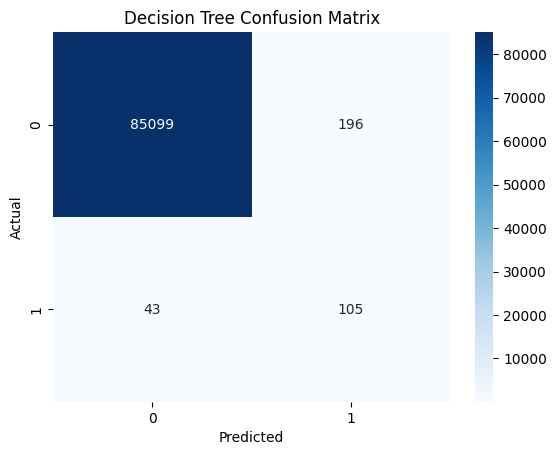


Random Forest
Accuracy: 0.9993797034280163
Precision: 0.8518518518518519
Recall: 0.777027027027027
F1 Score: 0.8127208480565371


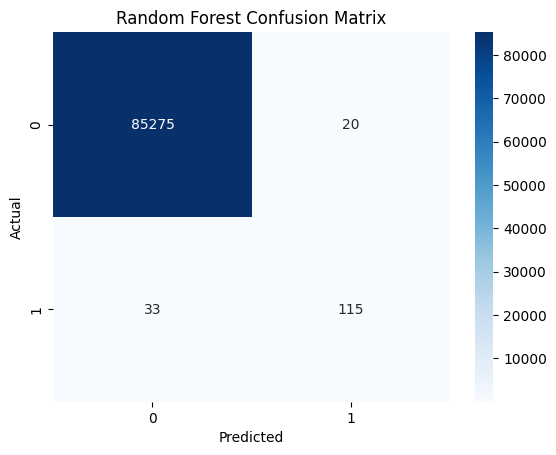

In [12]:
lr, y_pred_lr = evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000))
dt, y_pred_dt = evaluate_model("Decision Tree", DecisionTreeClassifier())
rf, y_pred_rf = evaluate_model("Random Forest", RandomForestClassifier())

In [ ]:
ann = Sequential()
ann.add(Dense(16, activation='relu', input_dim=X_train_res.shape[1]))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train_res, y_train_res, epochs=5, batch_size=32, verbose=1)

y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred_ann)
prec = precision_score(y_test, y_pred_ann)
rec = recall_score(y_test, y_pred_ann)
f1 = f1_score(y_test, y_pred_ann)

results.append(["ANN", acc, prec, rec, f1])

print("\nANN")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test, y_pred_ann)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("ANN Confusion Matrix")
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
12439/12439 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9873 - loss: 0.0374
Epoch 2/5
12439/12439 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9980 - loss: 0.0087
Epoch 3/5
12439/12439 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.9987 - loss: 0.0059
Epoch 4/5
12439/12439 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.9989 - loss: 0.0050
Epoch 5/5
 9207/12439 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9991 - loss: 0.0045

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
print(results_df)

In [ ]:
rf_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="Random Forest (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


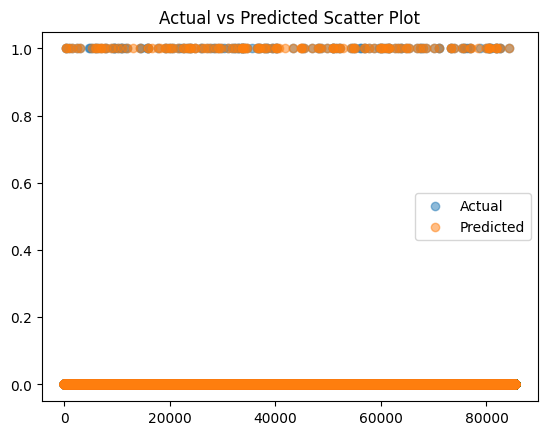

In [16]:
plt.figure()
plt.scatter(range(len(y_test)), y_test, label='Actual', alpha=0.5)
plt.scatter(range(len(y_pred_rf)), y_pred_rf, label='Predicted', alpha=0.5)

plt.title("Actual vs Predicted Scatter Plot")
plt.legend()
plt.show()